# Final Evaluation Summary
## Module 5: System Performance Evaluation

Notebook nay tong hop ket qua evaluation cua cac module trong do an va chia thanh tung cell de ban chay lan luot.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

RESULTS_DIR = REPO_ROOT / 'results'
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

REPO_ROOT

WindowsPath('C:/Users/ASUS/Documents/Các môn CS/Tư Duy Tính Toán/Đồ án/student-risk-warning-system')

### 1. Nap metrics tung module

In [2]:
MODULE_FILES = {
    'Module 1 - Academic Risk': 'metrics_module1.csv',
    'Module 2 - Lifestyle Risk': 'metrics_module2.csv',
    'Module 3 - Sentiment Risk': 'metrics_module3.csv',
    'Module 4 - Decision Layer': 'metrics_module4.csv',
}

def load_metric_file(module_name: str, file_name: str) -> pd.DataFrame:
    df = pd.read_csv(RESULTS_DIR / file_name)
    df['module'] = module_name
    return df

raw_metrics = pd.concat(
    [load_metric_file(module_name, file_name) for module_name, file_name in MODULE_FILES.items()],
    ignore_index=True,
)

raw_metrics.head(12)

,metric,value,module
0,accuracy,0.85,Module 1 - Academic Risk
1,precision,0.82,Module 1 - Academic Risk
2,recall,0.88,Module 1 - Academic Risk
3,f1_score,0.85,Module 1 - Academic Risk
4,model_name,gradient_boosting,Module 2 - Lifestyle Risk
5,accuracy,0.8469808278086365,Module 2 - Lifestyle Risk
6,precision,0.8566784869976359,Module 2 - Lifestyle Risk
7,recall,0.8870869033047736,Module 2 - Lifestyle Risk
8,f1_score,0.8716175586289837,Module 2 - Lifestyle Risk
9,roc_auc,0.9194842122196876,Module 2 - Lifestyle Risk


### 2. Tao bang tong hop de bao cao

In [3]:
metrics_table = (
    raw_metrics.pivot(index='module', columns='metric', values='value')
    .reset_index()
)

numeric_columns = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
for col in numeric_columns:
    if col in metrics_table.columns:
        metrics_table[col] = pd.to_numeric(metrics_table[col], errors='coerce')

ordered_columns = ['module', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'model_name']
metrics_table = metrics_table[[col for col in ordered_columns if col in metrics_table.columns]]
metrics_table = metrics_table.sort_values('f1_score', ascending=False).reset_index(drop=True)

metrics_table.style.format({col: '{:.3f}' for col in numeric_columns if col in metrics_table.columns})

metric,module,accuracy,precision,recall,f1_score,roc_auc,model_name
0,Module 2 - Lifestyle Risk,0.847,0.857,0.887,0.872,0.919,gradient_boosting
1,Module 4 - Decision Layer,0.870,0.840,0.890,0.860,nan,nan
2,Module 1 - Academic Risk,0.850,0.820,0.880,0.850,nan,nan
3,Module 3 - Sentiment Risk,0.750,0.720,0.780,0.750,nan,nan


### 3. Ve bieu do so sanh cac metric chinh

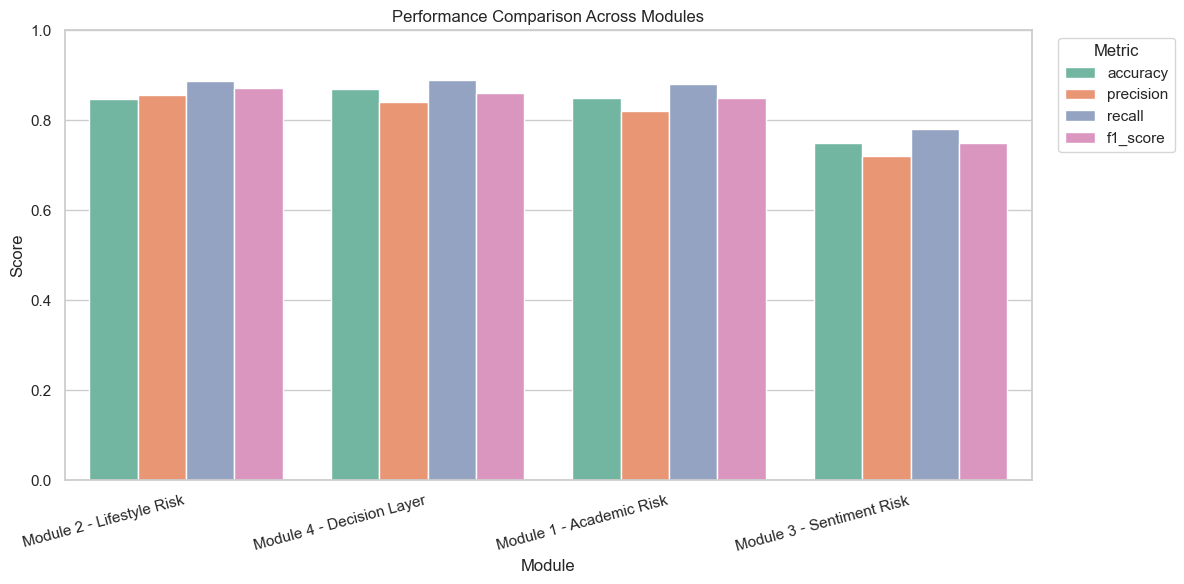

In [4]:
plot_columns = [col for col in ['accuracy', 'precision', 'recall', 'f1_score'] if col in metrics_table.columns]
plot_df = metrics_table.melt(id_vars='module', value_vars=plot_columns, var_name='metric', value_name='score')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=plot_df, x='module', y='score', hue='metric')
ax.set_title('Performance Comparison Across Modules')
ax.set_xlabel('Module')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4. Ve heatmap de nhin nhanh diem manh yeu tung module

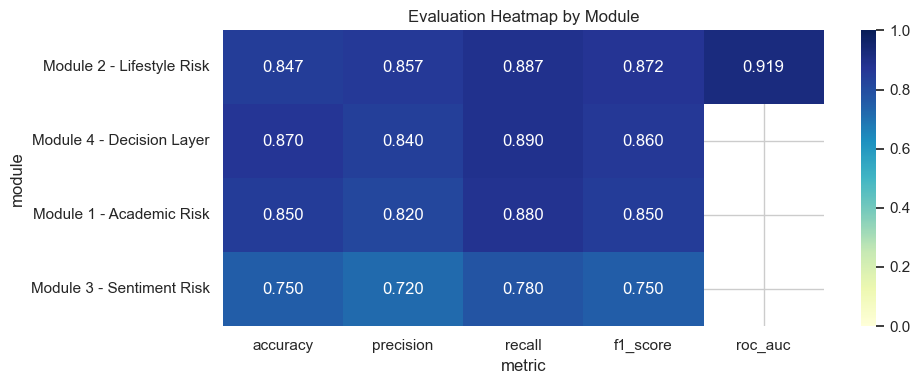

In [5]:
heatmap_columns = [col for col in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc'] if col in metrics_table.columns]
heatmap_df = metrics_table.set_index('module')[heatmap_columns]

plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', vmin=0, vmax=1, fmt='.3f')
plt.title('Evaluation Heatmap by Module')
plt.tight_layout()
plt.show()

### 5. Xem chi tiet phan so sanh model cua Module 2

In [6]:
module2_comparison = pd.read_csv(RESULTS_DIR / 'module2_model_comparison.csv')
module2_comparison

,model_name,accuracy,precision,recall,f1_score,roc_auc
0,gradient_boosting,0.846981,0.856678,0.887087,0.871618,0.919484
1,logistic_regression,0.844831,0.857867,0.880967,0.869263,0.918660
2,svm_rbf,0.840710,0.849339,0.884945,0.866777,0.901548
3,random_forest,0.839634,0.851347,0.879743,0.865312,0.915035


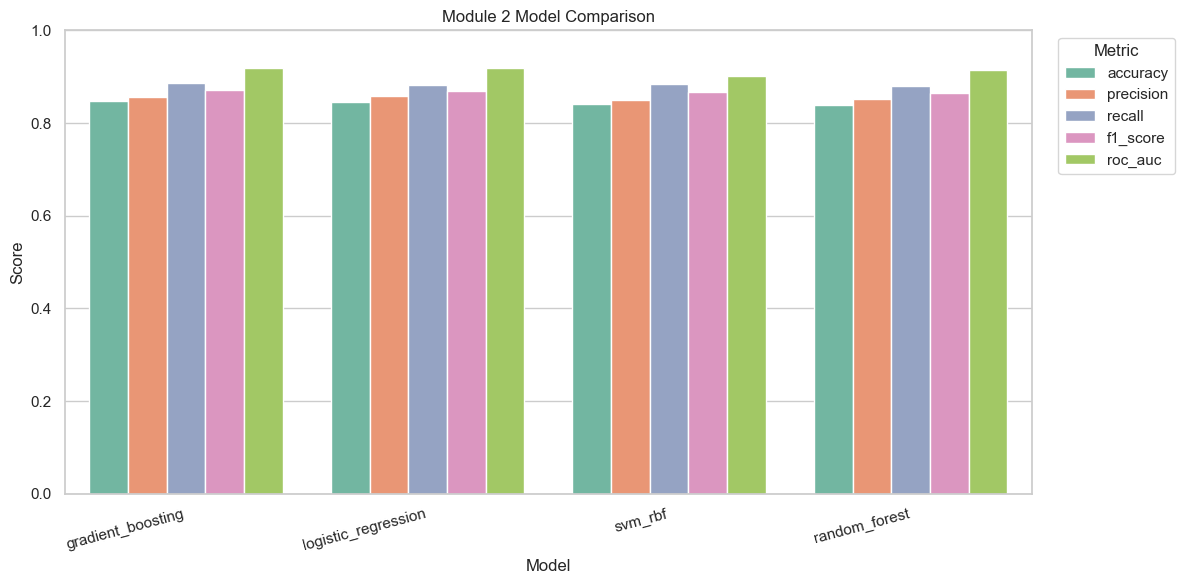

In [7]:
module2_plot = module2_comparison.melt(id_vars='model_name', value_vars=['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc'], var_name='metric', value_name='score')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=module2_plot, x='model_name', y='score', hue='metric')
ax.set_title('Module 2 Model Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6. Xem mau du doan holdout cua Module 2

In [8]:
holdout_preview = pd.read_csv(RESULTS_DIR / 'module2_holdout_preview.csv')
holdout_preview.head(10)

,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Age,Gender,true_label,predicted_label,lifestyle_score
0,2.0,6.37,3.0,2.0,0.0,1,11.0,5.0,1,20.0,Female,1,1,0.959163
1,2.0,7.22,4.0,1.0,1.0,1,8.0,5.0,1,31.0,Male,0,1,0.703996
2,3.0,7.88,4.0,1.0,1.0,1,12.0,1.0,0,20.0,Female,1,1,0.679523
3,5.0,5.65,5.0,0.0,2.0,0,3.0,3.0,1,28.0,Female,0,0,0.362760
4,3.0,6.63,2.0,2.0,1.0,1,6.0,1.0,0,29.0,Male,1,1,0.564448
5,1.0,7.25,5.0,2.0,2.0,1,12.0,1.0,0,24.0,Female,0,0,0.145687
6,3.0,9.89,2.0,3.0,0.0,0,10.0,3.0,1,30.0,Male,0,0,0.351508
7,4.0,9.21,1.0,0.0,0.0,1,9.0,1.0,0,30.0,Male,0,1,0.931887
8,1.0,6.73,1.0,3.0,2.0,0,0.0,2.0,0,29.0,Male,0,0,0.020744
9,5.0,9.74,1.0,3.0,1.0,1,1.0,5.0,0,24.0,Male,1,1,0.961795


In [9]:
holdout_preview['correct_prediction'] = holdout_preview['true_label'] == holdout_preview['predicted_label']
holdout_preview['correct_prediction'].value_counts().rename(index={True: 'Correct', False: 'Incorrect'})

correct_prediction
Correct      407
Incorrect     93
Name: count, dtype: int64

### 7. Nhan xet nhanh

In [10]:
best_module = metrics_table.iloc[0]
print(f"Module co F1-score cao nhat: {best_module['module']} ({best_module['f1_score']:.3f})")

if 'roc_auc' in metrics_table.columns:
    best_roc = metrics_table.dropna(subset=['roc_auc']).sort_values('roc_auc', ascending=False).iloc[0]
    print(f"Module co ROC-AUC cao nhat: {best_roc['module']} ({best_roc['roc_auc']:.3f})")

if 'model_name' in metrics_table.columns:
    module2_row = metrics_table.loc[metrics_table['module'] == 'Module 2 - Lifestyle Risk']
    if not module2_row.empty:
        print(f"Model duoc chon o Module 2: {module2_row.iloc[0]['model_name']}")

Module co F1-score cao nhat: Module 2 - Lifestyle Risk (0.872)
Module co ROC-AUC cao nhat: Module 2 - Lifestyle Risk (0.919)
Model duoc chon o Module 2: gradient_boosting
